# Linear systems, linear and non linear least squares

In [1]:
import ten
import numpy as np
import matplotlib.pyplot as plt
ten.set_seed(123)

## Linear system

In [2]:
A = ten.random.rand_norm((4, 4))
b = ten.random.rand_norm([4])

In [3]:
# Solve linear system using qr decompositon (default)
xqr = ten.linalg.solve(A, b)
xqr

tensor<float32,4>
-0.678463
-0.639513
0.199401
-1.39459

In [4]:
# Solve using LU decomposition
xlu = ten.linalg.solve(A, b, "lu")
xlu

tensor<float32,4>
-0.678463
-0.639513
0.199401
-1.39459

In [5]:
# Solve using SVD decomposition
xsvd = ten.linalg.solve(A, b, "svd")
xsvd

tensor<float32,4>
-0.678463
-0.639513
0.199401
-1.39459

## Least squares

In [6]:
n = 4
Xnp = np.ones((n, 2), dtype = np.float32)
for i in range(n):
    Xnp[i,1] = i + 1.
ynp = np.array([6., 5., 7., 10.]).astype(np.float32)

In [7]:
X = ten.from_numpy(Xnp)
y = ten.from_numpy(ynp)

In [8]:
beta = ten.linalg.lsqr(X, y)
beta

tensor<float32,2>
3.5
1.4

In [9]:
yhat = X @ beta
yhat

tensor<float32,4>
4.9
6.3
7.7
9.1

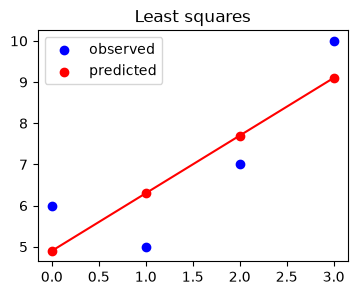

In [10]:
fig, axes = plt.subplots(figsize = (4, 3))
plt.scatter(range(n), ynp, color = "blue", label = "observed")
plt.scatter(range(n), yhat.to_numpy(), color = "red", label = "predicted")
plt.plot(yhat.to_numpy(), color = "red")
plt.title("Least squares")
plt.legend()
plt.show()

## Non linear least squares